# Анализ данных интернет-магазина (Online Retail II)

### Описание проекта
В данном проекте проводится анализ транзакций британского ритейлера. 
Цель — очистить данные, посмотреть возвраты, рассчитать ключевые бизнес-метрики (Revenue, Retention) 
и провести сегментацию клиентов.

### Стек технологий
* **SQL**
* **Python** (Pandas, Matplotlib/Seaborn)
* **Анализ**: EDA, RFM-анализ, когортный анализ.

### 1. Импорт библиотек и загрузка данных 

In [1]:
import squarify
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pandasql import sqldf
from datetime import datetime, timedelta

In [2]:
retail_df = pd.read_excel('online_retail_II.xlsx')
retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Для удобства переименуем столбец
retail_df = retail_df.rename(columns={'Customer ID': 'Customer_ID'})

### 2. Знакомство с нашими данными: кол-во строк и столбцов, типы переменных, а так же наличие пропущенных значений

In [4]:
retail_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer_ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


In [5]:
retail_df.isna().sum()

Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer_ID    107927
Country             0
dtype: int64

In [6]:
#Смотрим на пропущенные значения
missing_rows = retail_df[retail_df.isnull().any(axis=1)]

In [7]:
missing_rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom
577,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
525231,538159,21324,NaN,-18,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525232,538158,20892,NaN,-32,2010-12-09 17:17:00,0.00,NaN,United Kingdom
525233,538160,20956,NaN,288,2010-12-09 17:18:00,0.00,NaN,United Kingdom
525234,538161,46000S,Dotcom sales,-100,2010-12-09 17:25:00,0.00,NaN,United Kingdom


При детальном анализе пропусков обнаружено, что строки без `Customer_ID` также содержат аномальные значения: 
отрицательное количество (`Quantity`) и нулевую цену (`Price`). 
Это говорит о том, что данные строки являются системными списаниями, корректировками или техническими сбоями, 
а не реальными покупками клиентов. Для дальнейшего бизнес-анализа эти строки не имеют ценности и подлежат удалению.

In [8]:
# Фильтруем датафрейм: оставляем только реальные коммерческие транзакции
df_clean = retail_df.query('Customer_ID.notna()')

In [9]:
# Изменим тип данных для Customer_ID
df_clean['Customer_ID'] = df_clean['Customer_ID'].astype(int)

/var/folders/b9/gdxcnrhd687595trkrczsc340000gn/T/ipykernel_27216/2890365319.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Customer_ID'] = df_clean['Customer_ID'].astype(int)


In [10]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 417534 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      417534 non-null  object        
 1   StockCode    417534 non-null  object        
 2   Description  417534 non-null  object        
 3   Quantity     417534 non-null  int64         
 4   InvoiceDate  417534 non-null  datetime64[ns]
 5   Price        417534 non-null  float64       
 6   Customer_ID  417534 non-null  int64         
 7   Country      417534 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 28.7+ MB


### 3. Анализ клиентского оттока и возвратов (Cancellations & Returns Analysis)

In [11]:
# Посмотрим отмены заказов
df_clean[df_clean['Invoice'].str.lower().str.startswith('c', na=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321,Australia
...,...,...,...,...,...,...,...,...
524695,C538123,22956,36 FOIL HEART CAKE CASES,-2,2010-12-09 15:41:00,2.10,12605,Germany
524696,C538124,M,Manual,-4,2010-12-09 15:43:00,0.50,15329,United Kingdom
524697,C538124,22699,ROSES REGENCY TEACUP AND SAUCER,-1,2010-12-09 15:43:00,2.95,15329,United Kingdom
524698,C538124,22423,REGENCY CAKESTAND 3 TIER,-1,2010-12-09 15:43:00,12.75,15329,United Kingdom


In [12]:
# Посмотрим число Quantity < 0
df_clean.query('Quantity < 0').shape[0]

9839

Буква «C» (Cancellations) в номере счета всегда идет в паре с отрицательным количеством.
Это значит, что система фиксирует отмену заказа как «минусовую» покупку.

В этом разделе мы исследуем те самые 9839 строк с отрицательным количеством. Мы выделим их в отдельный датафрейм, чтобы понять:
- Какие товары возвращают чаще всего.
- Сколько денег теряет бизнес на отменах.
- Есть ли клиенты с аномально высоким числом возвратов.

In [13]:
cancels_df = df_clean.query('Quantity < 0')

In [14]:
# Считаем топ-10 самых возвращаемых товаров
top_returns = cancels_df.groupby('Description')['Quantity'].sum().abs().reset_index().sort_values(by='Quantity', ascending=False).head(10)
top_returns

,Description,Quantity
1656,ROTATING SILVER ANGELS T-LIGHT HLDR,9363
1812,SET/6 FRUIT SALAD PAPER CUPS,7128
1811,SET/6 FRUIT SALAD PAPER PLATES,7008
1448,POP ART PEN CASE & PENS,5184
206,BLACK SILVER FLOWER T-LIGHT HOLDER,5040
1194,MULTICOLOUR SPRING FLOWER MUG,4993
1991,TEATIME PEN CASE & PENS,4632
2098,WHITE BIRD GARDEN DESIGN MUG,4320
1679,S/4 BLUE ROUND DECOUPAGE BOXES,3940
1995,THE KING GIFT BAG,3744


Наблюдается аномальный объем товаров, при этом данные ограничиваются лишь десятью основными позициями по отменам.

In [15]:
# Посмотрим заказы, включающие в себя эти товары:
cancels_df[cancels_df['Description'].isin(top_returns['Description'])]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
24151,C491398,16046,TEATIME PEN CASE & PENS,-24,2009-12-10 16:45:00,0.85,12933,United Kingdom
69897,C495585,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-3,2010-01-26 10:17:00,1.25,18223,United Kingdom
106382,C499530,85184D,S/4 BLUE ROUND DECOUPAGE BOXES,-4,2010-03-01 11:28:00,2.95,13446,United Kingdom
156604,C504322,37340,MULTICOLOUR SPRING FLOWER MUG,-1,2010-04-12 14:56:00,0.85,13564,United Kingdom
294275,C518057,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,-288,2010-08-04 11:51:00,0.19,15873,United Kingdom
359630,C524235,16047,POP ART PEN CASE & PENS,-5184,2010-09-28 11:02:00,0.08,14277,France
359636,C524235,37340,MULTICOLOUR SPRING FLOWER MUG,-4992,2010-09-28 11:02:00,0.10,14277,France
359653,C524235,85110,BLACK SILVER FLOWER T-LIGHT HOLDER,-4752,2010-09-28 11:02:00,0.07,14277,France
359654,C524235,85160A,WHITE BIRD GARDEN DESIGN MUG,-4320,2010-09-28 11:02:00,0.13,14277,France
359658,C524235,16046,TEATIME PEN CASE & PENS,-4608,2010-09-28 11:02:00,0.08,14277,France


In [16]:
# Посмотрим все отмены пользователя из Франции по заказу C524235
cancels_df.query('Invoice == "C524235"').Quantity.sum()

-87167

**Итоговый вывод по анализу отмен:**
Обнаружена аномальная транзакция (Invoice C524235), в рамках которой было "отменено" суммарно 87 167 единиц товара за одну операцию. Такие объемы подтверждают наличие технических корректировок или оптовых списаний. Для корректного расчета розничных бизнес-метрик (Retention, средний чек, LTV) все строки с отрицательным количеством и отменами будут удалены из основного датасета.

In [17]:
# Финальная чистка
df_clean = df_clean.query('Quantity > 0')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 407695 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      407695 non-null  object        
 1   StockCode    407695 non-null  object        
 2   Description  407695 non-null  object        
 3   Quantity     407695 non-null  int64         
 4   InvoiceDate  407695 non-null  datetime64[ns]
 5   Price        407695 non-null  float64       
 6   Customer_ID  407695 non-null  int64         
 7   Country      407695 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 28.0+ MB


In [18]:
df_clean.to_csv('cleaned_retail.csv', index=False)

⚠️ **Важное методологическое допущение:**
Вместе с крупными оптовыми списаниями из датасета были удалены и мелкие розничные возвраты (Cancellations). 
В рамках данного проекта мы фокусируемся на анализе успешных продаж (Gross Sales) и поиске закономерностей в поведении покупателей. 
В реальной бизнес-практике для более точного расчета чистой выручки (Net Sales) потребовалось бы сопоставление каждой строки возврата с исходной строкой покупки по `InvoiceDate` и `CustomerID`.

### 4. Исследовательский анализ данных (EDA)

#### 🛍️ Задача 1. Топ-10 самых продаваемых товаров

In [19]:
# Загружаем наш чистый файл
df_clean = pd.read_csv('cleaned_retail.csv')

In [20]:
# Создаем функцию-помощник
pysqldf = lambda q: sqldf(q, globals())

In [21]:
query = """
SELECT Description, SUM(Quantity) AS Quantity
FROM df_clean
GROUP BY Description
ORDER BY Quantity DESC
LIMIT 10
"""

In [22]:
# Запускаем
pysqldf(query)

,Description,Quantity
0,WHITE HANGING HEART T-LIGHT HOLDER,56915
1,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54754
2,BROCADE RING PURSE,48166
3,PACK OF 72 RETRO SPOT CAKE CASES,45156
4,ASSORTED COLOUR BIRD ORNAMENT,44551
5,60 TEATIME FAIRY CAKE CASES,35806
6,PACK OF 60 PINK PAISLEY CAKE CASES,31006
7,JUMBO BAG RED RETROSPOT,29578
8,SMALL POPCORN HOLDER,25718
9,BLACK AND WHITE PAISLEY FLOWER MUG,25685


#### Топ-10 самых продаваемых товаров: 
Лидером продаж является `WHITE HANGING HEART T-LIGHT HOLDER` с общим объемом продаж более 56 тыс. единиц. 
В топ-10 также вошли кондитерские формы и декор, что подтверждает специфику магазина (подарки и товары для дома).

#### 💰 Задача 2. Какие 10 товаров принесли магазину больше всего выручки 🤔

In [23]:
query_revenue = """
SELECT Description, SUM(Quantity * Price) AS Revenue
FROM df_clean
GROUP BY Description
ORDER BY Revenue DESC
LIMIT 10
"""

# Запускаем
pysqldf(query_revenue)

,Description,Revenue
0,WHITE HANGING HEART T-LIGHT HOLDER,151624.31
1,REGENCY CAKESTAND 3 TIER,143893.35
2,Manual,98560.64
3,ASSORTED COLOUR BIRD ORNAMENT,70493.83
4,JUMBO BAG RED RETROSPOT,51759.30
5,POSTAGE,48741.08
6,ROTATING SILVER ANGELS T-LIGHT HLDR,40186.65
7,PAPER CHAIN KIT 50'S CHRISTMAS,36933.50
8,PARTY BUNTING,35035.90
9,EDWARDIAN PARASOL NATURAL,34044.75


#### 🏆 Наблюдение: Выявление лидера и фильтрация нецелевых позиций
При анализе выручки по товарам были сделаны следующие выводы:
1. **Абсолютный лидер:** Товар `WHITE HANGING HEART T-LIGHT HOLDER` подтвердил статус бестселлера, заняв 1-е место не только по количеству проданных штук, но и по суммарной выручке (более 151 тыс. у.е.).
2. **Обнаружение системного шума:** В топ-10 по выручке попали позиции `Manual` (ручные бухгалтерские проводки) и `POSTAGE` (почтовые сборы). 

**Решение:** Для того чтобы дальнейший анализ отражал только чистые розничные продажи товаров из каталога, было принято решение удалить строки с описанием `Manual` и `POSTAGE`. Это позволит избежать искажения показателей среднего чека и популярности категорий.

In [24]:
# Удаляем сервисные и ручные проводки
df_clean = df_clean.query("Description != 'Manual' and Description != 'POSTAGE'")

In [25]:
# Проверим, сколько строк осталось
df_clean.shape

(406531, 8)

#### 📈 Задача 3. Динамика продаж по месяцам

In [26]:
monthly_query = """
SELECT 
    strftime('%Y-%m', InvoiceDate) AS Month,
    SUM(Quantity * Price) AS Revenue
FROM df_clean
GROUP BY Month
ORDER BY Month ASC
"""

In [27]:
# Запускаем
monthly_revenue = pysqldf(monthly_query)
monthly_revenue

,Month,Revenue
0,2009-12,681544.720
1,2010-01,539007.892
2,2010-02,499964.686
3,2010-03,668977.191
4,2010-04,588228.902
5,2010-05,595218.530
6,2010-06,632715.900
7,2010-07,584108.530
8,2010-08,597351.220
9,2010-09,808575.061


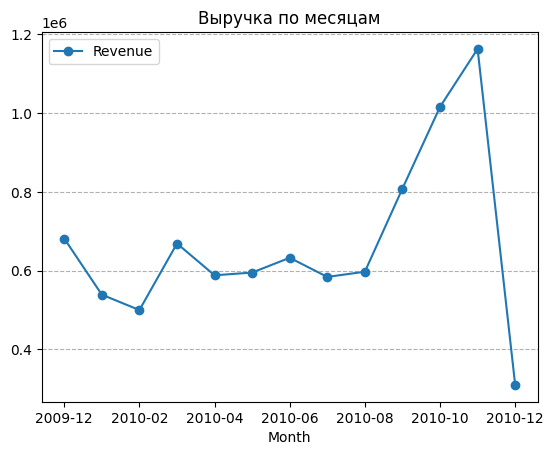

In [28]:
# Визуализируем данные
monthly_revenue.plot(x='Month', y='Revenue', kind='line', marker='o', title='Выручка по месяцам')
plt.grid(axis='y', linestyle='--')
plt.show()

In [29]:
# Видим спад в декабре. Посмотрим дату последних заказов в данных 
df_clean.sort_values(by='InvoiceDate', ascending=False).head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country
407694,538171,21931,JUMBO STORAGE BAG SUKI,2,2010-12-09 20:01:00,1.95,17530,United Kingdom
407645,538171,20777,CHRYSANTHEMUM NOTEBOOK,2,2010-12-09 20:01:00,1.65,17530,United Kingdom
407660,538171,20765,CHRYSANTHEMUM SKETCHBOOK,1,2010-12-09 20:01:00,3.75,17530,United Kingdom
407659,538171,21879,HEARTS GIFT TAPE,5,2010-12-09 20:01:00,0.65,17530,United Kingdom
407658,538171,21882,SKULLS TAPE,5,2010-12-09 20:01:00,0.65,17530,United Kingdom


#### 📈 Анализ сезонности и динамики выручки
На графике отчетливо видна выраженная сезонность продаж:
* **Пик продаж** приходится на ноябрь 2010 года (выручка > 1.16 млн), что связано с подготовкой потребителей к праздничному сезону.
* **Аномальное падение** в декабре 2010 года обусловлено не снижением спроса, а неполнотой данных в датасете (сбор данных прекращен 9 декабря).
* **Сравнение:** Выручка за неполный декабрь 2010 (9 дней) уже составляет почти половину от выручки полного декабря 2009 года, что указывает на рост бизнеса в годовом исчислении.

In [30]:
df_clean['Revenue'] = df_clean['Price'] * df_clean['Quantity']

#### 🧾 Задача 4. Сравнение стран по среднему чеку

In [31]:
# 1. Группируем по номеру чека и стране, считаем сумму выручки по этому чеку
invoice_revenue = df_clean.groupby(['Invoice', 'Country'])['Revenue'].sum().reset_index()

In [32]:
invoice_revenue

,Invoice,Country,Revenue
0,489434,United Kingdom,505.30
1,489435,United Kingdom,145.80
2,489436,United Kingdom,630.33
3,489437,United Kingdom,310.75
4,489438,United Kingdom,2286.24
...,...,...,...
19036,538167,United Kingdom,298.95
19037,538168,United Kingdom,318.70
19038,538169,United Kingdom,93.45
19039,538170,United Kingdom,317.59


In [33]:
# 2. Группируем уже только по стране и берем среднее (mean) от выручки чеков
countries_aov = invoice_revenue.groupby('Country')['Revenue'].mean().reset_index()

In [34]:
# 3. Сортируем, чтобы увидеть лидеров
countries_aov = countries_aov.sort_values(by='Revenue', ascending=False)
countries_aov

,Country,Revenue
21,Netherlands,2145.671935
8,Denmark,2013.954000
15,Israel,1599.700000
31,Thailand,1535.270000
20,Malta,1343.375000
9,EIRE,1156.127347
30,Switzerland,1143.955278
23,Norway,1100.871111
13,Greece,1098.897692
27,Singapore,1009.442500


#### 🌍 Анализ среднего чека (AOV) по странам
Расчет среднего чека выявил значительные различия в поведении покупателей:
1. **Лидеры:** Нидерланды и Дания имеют самый высокий средний чек (>2000 у.е.), что в 5 раз превышает показатель Великобритании. Это указывает на доминирование оптовых закупок в данных регионах.
2. **Великобритания:** Несмотря на лидерство в общей выручке, занимает лишь 32-е место по среднему чеку (419.5 у.е.), что характерно для розничного рынка с большим количеством мелких транзакций.

**Бизнес-рекомендация:** Рассмотреть возможность внедрения программ лояльности для "тяжелых" рынков (Нидерланды, Дания) и оптимизировать стоимость логистики для рынков с низким чеком (Нигерия, Бразилия и Польша).

### 📈👥 Задача 5. Анализ удержания клиентов (Retention)

В данном разделе мы переходим к анализу лояльности аудитории. 
Для бизнеса критически важно понимать, возвращаются ли клиенты за повторными покупками или 
магазин работает только на привлечение новых пользователей. 

**Метрика:** Посчитаем долю клиентов, совершивших 2 и более заказа (Retention Rate на уровне всей базы). 
Это даст нам верхнеуровневое понимание лояльности клиентов до того, как мы перейдем к более детальному когортному анализу.

In [35]:
# Считаем количество уникальных заказов (Invoice) для каждого клиента
orders_per_customer = df_clean.groupby('Customer_ID')['Invoice'].nunique()
orders_per_customer

Customer_ID
12346    11
12347     2
12348     1
12349     2
12351     1
         ..
18283     6
18284     1
18285     1
18286     2
18287     4
Name: Invoice, Length: 4298, dtype: int64

In [36]:
# Считаем, сколько людей заказали больше 1 раза
returning_customers = (orders_per_customer > 1).sum()
returning_customers

2874

In [37]:
# Считаем общий процент "возвращенцев"
retention_rate = ((returning_customers / orders_per_customer.count()) * 100).round(2)

In [38]:
print(f"Всего клиентов: {orders_per_customer.count()}")
print(f"Повторные заказы сделали: {returning_customers}")
print(f"Процент лояльных клиентов: {retention_rate:}%")

Всего клиентов: 4298
Повторные заказы сделали: 2874
Процент лояльных клиентов: 66.87%


**Вывод по лояльности:**
Уровень удержания клиентов составляет **66.87%**. Это очень высокий показатель для интернет-торговли. 
Две трети клиентов возвращаются за повторными покупками, что свидетельствует о высокой удовлетворенности 
ассортиментом и качеством обслуживания, а также о наличии стабильной базы оптовых покупателей.

### 📅 Задача 6. Когортный анализ

In [39]:
# Изменим тип столбца InvoiceDate в нашем очищенном датафрейме
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

In [40]:
# Создаем «Месяц заказа»
df_clean['OrderMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [41]:
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer_ID,Country,Revenue,OrderMonth
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009-12
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009-12
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009-12
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009-12


In [42]:
# Находим «Месяц рождения» клиента
df_clean['CohortMonth'] = df_clean.groupby('Customer_ID')['InvoiceDate'].transform('min').dt.to_period('M')

In [43]:
# Считаем «Возраст» заказа (Cohort Index)
df_clean['CohortIndex'] = (df_clean['OrderMonth'] - df_clean['CohortMonth']).apply(lambda x: x.n)

In [44]:
# Создадим Когортную таблицу
cohort_table = df_clean.groupby(['CohortMonth', 'CohortIndex'])['Customer_ID'].nunique().reset_index()

In [45]:
# Переименуем столбец Customer_ID
cohort_table.rename(columns={'Customer_ID': 'customer_count'}, inplace=True)

In [46]:
cohort_table.head()

,CohortMonth,CohortIndex,customer_count
0,2009-12,0,952
1,2009-12,1,336
2,2009-12,2,317
3,2009-12,3,405
4,2009-12,4,362


In [47]:
# Повернем нашу таблицу
cohort_table = pd.pivot_table(
    cohort_table, 
    index='CohortMonth', 
    columns='CohortIndex', 
    values='customer_count'
)

In [48]:
cohort_table

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,952.0,336.0,317.0,405.0,362.0,342.0,360.0,327.0,321.0,344.0,401.0,472.0,237.0
2010-01,382.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,106.0,121.0,115.0,38.0,NaN
2010-02,377.0,88.0,85.0,110.0,92.0,74.0,72.0,108.0,96.0,104.0,27.0,NaN,NaN
2010-03,439.0,84.0,102.0,106.0,103.0,90.0,109.0,134.0,122.0,35.0,NaN,NaN,NaN
2010-04,293.0,56.0,56.0,47.0,54.0,65.0,81.0,77.0,20.0,NaN,NaN,NaN,NaN
2010-05,254.0,40.0,43.0,44.0,45.0,65.0,54.0,20.0,NaN,NaN,NaN,NaN,NaN
2010-06,267.0,47.0,50.0,55.0,62.0,76.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,186.0,29.0,34.0,55.0,54.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,162.0,32.0,47.0,53.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
# 1. Берем первый столбец (размер когорты)
cohort_sizes = cohort_table.iloc[:, 0]

# 2. Делим всю таблицу на этот столбец по строкам (axis=0)
retention_matrix = cohort_table.divide(cohort_sizes, axis=0)

# 3. Округляем для красоты и переводим в проценты (необязательно, но наглядно)
retention_matrix = (retention_matrix * 100).round(1)

In [50]:
retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2009-12,100.0,35.3,33.3,42.5,38.0,35.9,37.8,34.3,33.7,36.1,42.1,49.6,24.9
2010-01,100.0,20.7,31.2,30.6,26.4,30.1,25.9,23.0,27.7,31.7,30.1,9.9,NaN
2010-02,100.0,23.3,22.5,29.2,24.4,19.6,19.1,28.6,25.5,27.6,7.2,NaN,NaN
2010-03,100.0,19.1,23.2,24.1,23.5,20.5,24.8,30.5,27.8,8.0,NaN,NaN,NaN
2010-04,100.0,19.1,19.1,16.0,18.4,22.2,27.6,26.3,6.8,NaN,NaN,NaN,NaN
2010-05,100.0,15.7,16.9,17.3,17.7,25.6,21.3,7.9,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,17.6,18.7,20.6,23.2,28.5,6.7,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,15.6,18.3,29.6,29.0,10.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,19.8,29.0,32.7,11.1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 🎨 Тепловая карта (Heatmap)

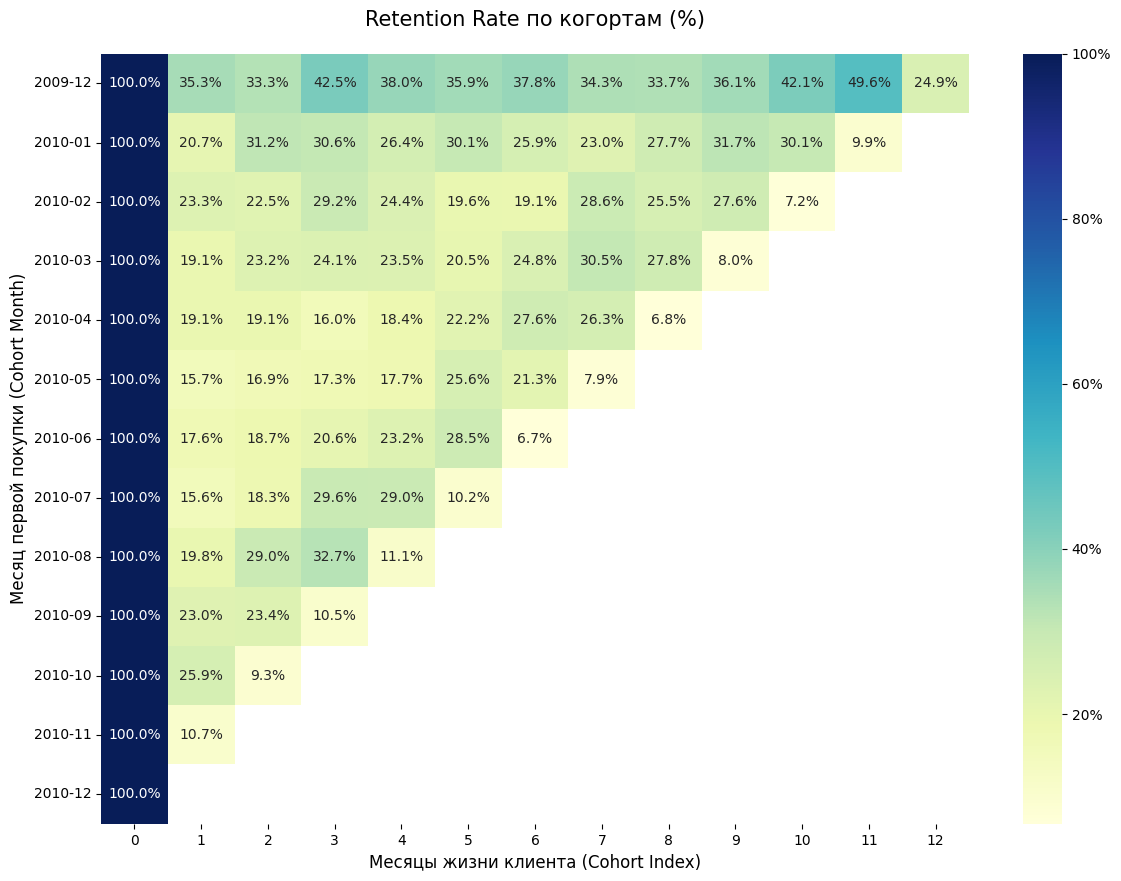

In [51]:
plt.figure(figsize=(14, 10))

# Строим хитмапу
# 1. С помощью fmt='.1f' и функции ниже мы добавим символ % в каждую ячейку
# 2. Параметр cbar_kws={'format': '%.0f%%'} добавит % на шкалу справа
ax = sns.heatmap(retention_matrix, 
                 annot=True, 
                 fmt='.1f', 
                 cmap='YlGnBu', 
                 cbar_kws={'format': '%.0f%%'})

# Добавляем символ % ко всем текстовым подписям внутри ячеек
for t in ax.texts: 
    t.set_text(t.get_text() + "%")

# Поворачиваем подписи по оси Y (месяцы) горизонтально
plt.yticks(rotation=0)

plt.title('Retention Rate по когортам (%)', fontsize=15, pad=20)
plt.xlabel('Месяцы жизни клиента (Cohort Index)', fontsize=12)
plt.ylabel('Месяц первой покупки (Cohort Month)', fontsize=12)

plt.show()


Мы провели когортный анализ, сгруппировав клиентов по месяцу их первой покупки.

**Ключевые выводы:**
* **Высокая лояльность базы:** Первая когорта (2009-12) демонстрирует аномально высокое удержание — спустя год почти 50% клиентов остаются активными. Это подтверждает наличие сильного ядра оптовых покупателей.
* **Сезонный всплеск:** В ноябре 2010 года наблюдается рост активности во всех "старых" когортах. Это указывает на циклическую модель потребления — клиенты возвращаются за покупками ежегодно в преддверии праздников.
* **Качество новых когорт:** Удержание новых клиентов (2010-04 — 2010-08) значительно ниже и составляет в среднем 15-20% на второй месяц. Это зона роста для маркетинга по удержанию (CRM-маркетинг).

### 📊 Задача 6. RFM-анализ

In [52]:
# Для удобства отформатируем дату до дней
df_clean['formatted_date'] = pd.to_datetime(df_clean['InvoiceDate'].dt.date)

In [53]:
# Будем считать, что текущая дата - это максимальная дата покупки + 1 день
today_date = df_clean.formatted_date.max() + pd.DateOffset(days=1)

In [54]:
# Найдем сразу все требуемые метрики
# R - время от последней покупки пользователя до текущей даты
# F - суммарное количество покупок у пользователя за всё время (покупка = заказ)
# M - сумма покупок за всё время
rfm = df_clean.groupby('Customer_ID', as_index = False) \
    .agg({'formatted_date': lambda x:(today_date - x.max()).days, 'Invoice': 'nunique', 'Revenue': 'sum'}) \
    .rename(columns = {'formatted_date': 'R', 'Invoice': 'F', 'Revenue': 'M'})

rfm.head()

,Customer_ID,R,F,M
0,12346,165,11,372.86
1,12347,3,2,1323.32
2,12348,74,1,221.16
3,12349,43,2,2221.14
4,12351,11,1,300.93


* **Recency (Давность) —** Как давно клиент совершил покупку?
* **Frequency (Частота) —** Как часто они совершают покупки?
* **Monetary Value (Денежная ценность) —** Сколько они тратят?

In [55]:
# Из-за того, что клиенты в основном совершают 1 заказ, почти все квантили для метрики F получаются одинаковые
# Будем использовать собственную кластеризацию для всех метрик, с оглядкой на полученные квантили
rfm.F.value_counts()

F
1      1424
2       803
3       523
4       376
5       245
       ... 
42        1
41        1
134       1
45        1
89        1
Name: count, Length: 64, dtype: int64

In [56]:
# Для R и M
rfm['r_score'] = pd.qcut(rfm['R'], 5, labels=[5, 4, 3, 2, 1])
rfm['m_score'] = pd.qcut(rfm['M'], 5, labels=[1, 2, 3, 4, 5])

In [57]:
# Для F используем ранг
rfm['f_score'] = pd.qcut(rfm['F'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

In [58]:
# Создаем итоговый склеенный балл
rfm['RFM_Score'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str) + rfm['m_score'].astype(str)

In [59]:
# Посмотрим всех клиентов с баллом 555
rfm.query('RFM_Score == "555"').sort_values(by='M', ascending=True)

,Customer_ID,R,F,M,r_score,m_score,f_score,RFM_Score
159,12600,7,12,2137.88,5,5,5,555
873,13611,10,7,2147.73,5,5,5,555
3760,17552,8,10,2154.88,5,5,5,555
3896,17732,8,8,2166.42,5,5,5,555
2584,15965,3,10,2167.45,5,5,5,555
...,...,...,...,...,...,...,...,...
935,13694,9,94,131443.19,5,5,5,555
1831,14911,1,188,144142.25,5,5,5,555
1265,14156,7,97,188388.29,5,5,5,555
1630,14646,10,73,247613.50,5,5,5,555


In [60]:
segs = {
    r'[1-2][1-2]': 'Спящие',                # Давно были, мало покупок
    r'[1-2][3-4]': 'Под риском ухода',      # Раньше были активны, но давно пропали
    r'[1-2]5': 'Нельзя терять',             # Бывшие VIP, которые почти ушли
    r'3[1-2]': 'Засыпающие',                # Средняя давность, мало покупок
    r'33': 'Требуют внимания',              # Середнячки
    r'[3-4][4-5]': 'Лояльные клиенты',      # Постоянные и активные
    r'41': 'Перспективные',                 # Недавние, но пока один-два заказа
    r'51': 'Новички',                       # Только что пришли
    r'[4-5][2-3]': 'Потенциальные лоялисты',# Недавние со средним чеком
    r'5[4-5]': 'Чемпионы'                   # Самые свежие и самые активные
}

# Применяем сегментацию по R и F
rfm['Segment'] = rfm['r_score'].astype(str) + rfm['f_score'].astype(str)
rfm['Segment'] = rfm['Segment'].replace(segs, regex=True)

In [61]:
rfm_stats = rfm.groupby('Segment').agg({
    'R': 'mean',
    'F': 'mean',
    'M': ['mean', 'count']
}).round(1)

In [62]:
rfm_stats

R     F       M      
                         mean  mean    mean count
Segment                                          
Засыпающие               53.1   1.2   439.6   330
Лояльные клиенты         35.9   6.8  2711.8   735
Нельзя терять           124.6   9.2  3845.4    80
Новички                   8.4   1.0   376.3    49
Перспективные            25.9   1.0   500.8    88
Под риском ухода        150.9   3.1  1164.9   616
Потенциальные лоялисты   18.8   2.0   720.8   519
Спящие                  212.3   1.1   386.8  1022
Требуют внимания         53.1   2.4  1012.7   199
Чемпионы                  7.1  12.5  6799.7   660

In [63]:
# Группируем по сегментам и смотрим средние показатели
rfm_summary = rfm.groupby('Segment').agg({
    'R': 'mean',
    'F': 'mean',
    'M': ['mean', 'count']
}).round(1)

# Переименуем колонки для красоты
rfm_summary.columns = ['Средняя давность', 'Средняя частота', 'Средний чек', 'Кол-во клиентов']
rfm_summary = rfm_summary.sort_values(by='Кол-во клиентов', ascending=False)

print(rfm_summary)

                        Средняя давность  Средняя частота  Средний чек  \
Segment                                                                  
Спящие                             212.3              1.1        386.8   
Лояльные клиенты                    35.9              6.8       2711.8   
Чемпионы                             7.1             12.5       6799.7   
Под риском ухода                   150.9              3.1       1164.9   
Потенциальные лоялисты              18.8              2.0        720.8   
Засыпающие                          53.1              1.2        439.6   
Требуют внимания                    53.1              2.4       1012.7   
Перспективные                       25.9              1.0        500.8   
Нельзя терять                      124.6              9.2       3845.4   
Новички                              8.4              1.0        376.3   

                        Кол-во клиентов  
Segment                                  
Спящие                     

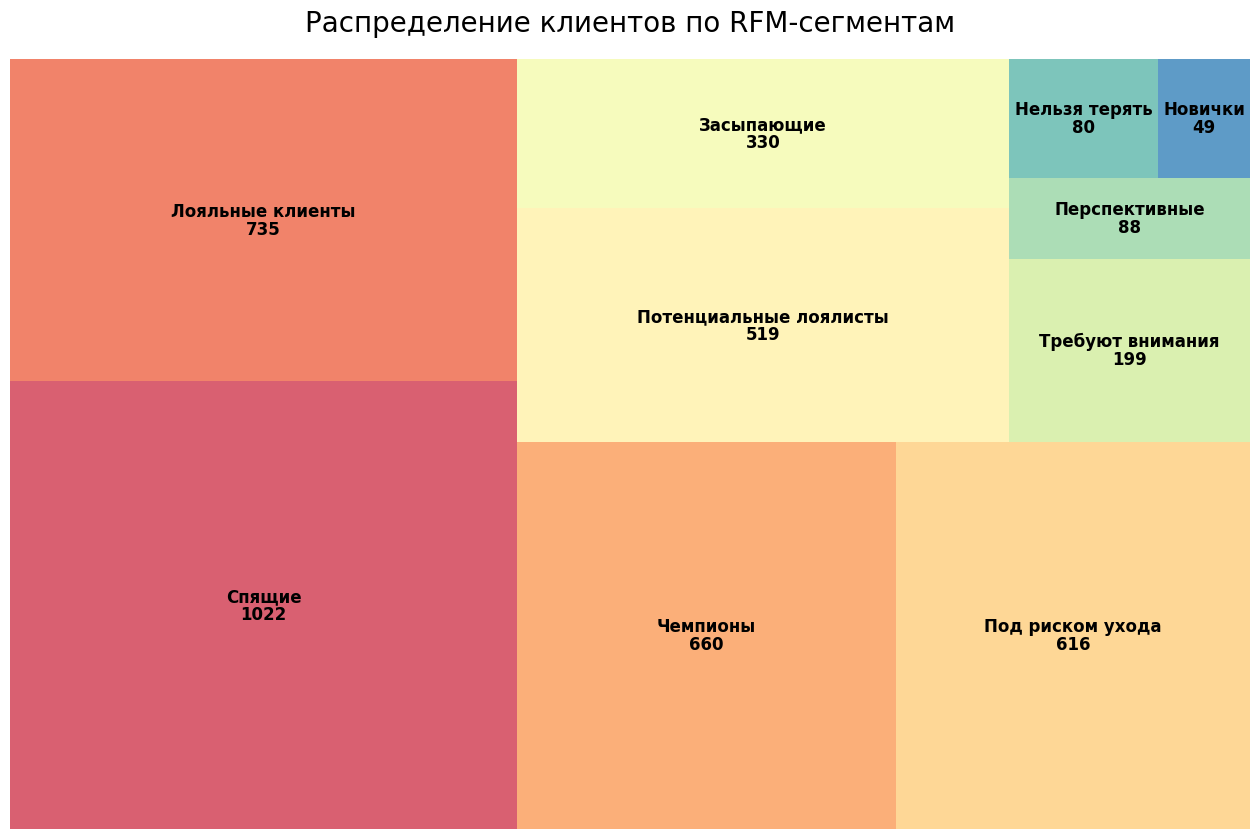

In [64]:
# Подготовим данные
df_plot = rfm.groupby('Segment').agg({'Customer_ID': 'count'}).reset_index()
df_plot.columns = ['Segment', 'Count']
df_plot = df_plot.sort_values(by='Count', ascending=False)

# Настройка цветов и шрифтов
plt.figure(figsize=(16, 10))
colors = sns.color_palette('Spectral', len(df_plot))

# Строим график
squarify.plot(sizes=df_plot['Count'], 
              label=df_plot['Segment'], 
              value=df_plot['Count'], 
              alpha=0.8, 
              color=colors,
              text_kwargs={'fontsize': 12, 'weight': 'bold'})

plt.title('Распределение клиентов по RFM-сегментам', fontsize=20, pad=20)
plt.axis('off') # Убираем оси
plt.show()

Мы разделили клиентскую базу на 10 сегментов на основе давности (R), частоты (F) и суммы покупок (M).

**Ключевые выводы:**
* **Ядро бизнеса:** Сегменты «Чемпионы» и «Лояльные клиенты» суммарно составляют около 32% базы (1395 чел.), но приносят основную выручку с самым высоким средним чеком (до 6799 у.е.).
* **Зона риска:** Самый многочисленный сегмент — «Спящие» (1022 чел.). Их средний чек минимален (386 у.е.), а давность визита составляет более 200 дней. Это указывает на большой пласт клиентов, совершивших разовую покупку и не вернувшихся.
* **Упущенные возможности:** Группа «Нельзя терять» (80 чел.) имеет высокую частоту покупок и высокий чек (3845 у.е.), но давно не проявляла активность (124 дня). Это приоритетная группа для реактивации.

**Рекомендации:**
1. **Для Чемпионов:** Программа лояльности, ранний доступ к новинкам, персональные менеджеры (т.к. это явно оптовики).
2. **Для группы «Нельзя терять»:** Провести опрос о качестве сервиса и предложить крупную персональную скидку на следующий заказ.
3. **Для Спящих:** Автоматическая рассылка с подборкой хитов продаж, чтобы попытаться вернуть их в воронку с минимальными затратами.